[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/chain.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58238466-lesson-4-chain)

# Chain

## Review

We built a simple graph with nodes, normal edges, and conditional edges.

## Goals

Now, let's build up to a simple chain that combines 4 [concepts](https://python.langchain.com/v0.2/docs/concepts/):

* Using [chat messages](https://python.langchain.com/v0.2/docs/concepts/#messages) as our graph state
* Using [chat models](https://python.langchain.com/v0.2/docs/concepts/#chat-models) in graph nodes
* [Binding tools](https://python.langchain.com/v0.2/docs/concepts/#tools) to our chat model
* [Executing tool calls](https://python.langchain.com/v0.2/docs/concepts/#functiontool-calling) in graph nodes 

![Screenshot 2024-08-21 at 9.24.03 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dd607b08df5e1101_chain1.png)

In [1]:
%%capture --no-stderr
%pip install --quiet -U  langchain_core langgraph langchain-ollama  # langchain_openai


## Messages

Chat models can use [`messages`](https://python.langchain.com/v0.2/docs/concepts/#messages), which capture different roles within a conversation. 

LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`. 

These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call. 

Let's create a list of messages. 

Each message can be supplied with a few things:

* `content` - content of the message
* `name` - optionally, a message author 
* `response_metadata` - optionally, a dict of metadata (e.g., often populated by model provider for `AIMessages`)

In [2]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching how searching for advanced B2B customers can use AI?", name="Model")]
messages.append(HumanMessage(content=f"Yes, in the context of Belgian business customers, how can we find them?",name="Peter"))
messages.append(AIMessage(content=f"Great, where would you start?", name="Model"))
messages.append(HumanMessage(content=f"I think building some tooling that can find larger business on the web, "
                             "that can use AI for improving business efficiency?", name="Peter"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching how searching for advanced B2B customers can use AI?
================================ Human Message =================================
Name: Peter

Yes, in the context of Belgian business customers, how can we find them?
================================== Ai Message ==================================
Name: Model

Great, where would you start?
================================ Human Message =================================
Name: Peter

I think building some tooling that can find larger business on the web, that can use AI for improving business efficiency?


## Try ollama

In [3]:
from langchain_ollama import OllamaLLM

llm = OllamaLLM(model="llama3")


## Chat Models

[Chat models](https://python.langchain.com/v0.2/docs/concepts/#chat-models) can use a sequence of message as input and support message types, as discussed above.

There are [many](https://python.langchain.com/v0.2/docs/concepts/#chat-models) to choose from! Let's work with OpenAI. 

Let's check that your `OPENAI_API_KEY` is set and, if not, you will be asked to enter it.

In [10]:
# import os, getpass

# def _set_env(var: str):
#     if not os.environ.get(var):
#         os.environ[var] = getpass.getpass(f"{var}: ")

# _set_env("OPENAI_API_KEY")

We can load a chat model and invoke it with out list of messages.

We can see that the result is an `AIMessage` with specific `response_metadata`.

In [11]:
# from langchain_openai import ChatOpenAI
# BASE="gpt-4o"
# # PREMIUM="01-preview"

# llm = ChatOpenAI(model=BASE)


langchain_core.messages.ai.AIMessage

In [4]:
result = llm.invoke(messages)
type(result)

str

In [5]:
result

"So you're looking to identify advanced B2B customers in Belgium who are interested in using AI-powered solutions to improve their business efficiency. That's a great target market!\n\nTo get started, let's break down the problem into smaller parts:\n\n1. **Define your ideal customer**: What specific characteristics do these advanced B2B customers share? Are they:\n\t* Large enterprises with a certain number of employees or revenue?\n\t* Industry-specific (e.g., manufacturing, finance, healthcare)?\n\t* Looking for solutions that address specific pain points (e.g., automation, data analysis, compliance)?\n2. **Gather data**: Collect information about these potential customers from various sources:\n\t* Public databases: Companies Register, LinkedIn, Crunchbase, etc.\n\t* Industry associations and publications\n\t* Social media platforms (Twitter, Facebook, etc.)\n3. **Use AI-powered tools to filter and prioritize**: Utilize natural language processing (NLP) and machine learning algorit

'So you\'re looking to identify advanced B2B customers in Belgium who are likely to be interested in solutions that improve business efficiency. That\'s a great starting point!\n\nTo begin with, I\'d suggest leveraging publicly available data sources to get an initial list of potential targets. Here are some ideas:\n\n1. **Company databases**: Utilize reputable company databases such as Kompass, Dun & Bradstreet (D&B), or Crunchbase to gather information on Belgian businesses. These databases often provide insights into company size, industry, and revenue.\n2. **Social media**: Analyze social media platforms like LinkedIn, Twitter, or Facebook to identify companies that are active in your target space. Look for keywords related to your solution and engage with those who seem interested.\n3. **News articles and press releases**: Monitor news articles and press releases from Belgian publications, such as Het Financieele Dagblad (FD) or De Tijd, to identify companies making headlines in areas relevant to your solution.\n4. **Industry reports and research studies**: Read industry reports and research studies from organizations like the European Commission, the National Bank of Belgium, or the Federation of Belgian Enterprises (FEB) to gain insights into the key sectors and industries in Belgium that might be interested in efficiency-improving solutions.\n5. **Google search**: Use Google search operators to find companies that are likely to be interested in your solution. For example, you could search for keywords like "Belgium" + "industry," "company," or "organization" along with terms related to business efficiency.\n\nOnce you\'ve gathered this initial list of potential targets, you can use AI-powered tools to further refine and prioritize the leads. Some strategies might include:\n\n1. **Machine learning-based filtering**: Use machine learning algorithms to analyze your data and filter out companies that don\'t meet specific criteria (e.g., company size, industry, or revenue).\n2. **Predictive lead scoring**: Implement a predictive lead scoring model that assigns scores based on factors like company size, growth rate, or social media engagement.\n3. **Content analysis**: Use AI-powered content analysis tools to analyze the language and tone used by companies in their marketing materials, social media posts, or website content. This can help you identify potential targets that are more likely to be interested in your solution.\n\nBy combining these approaches, you should be able to build a comprehensive list of advanced B2B customers in Belgium who might be interested in solutions that improve business efficiency.\n\nWhat do you think? Is there anything specific you\'d like to focus on or explore further?'


That sounds like a promising approach. Here are some steps and considerations for developing such a tool:\n\n1. **Define Your Target Audience:**\n   - Clearly define what constitutes "larger businesses" in the Belgian market. This could be based on revenue, employee size, industry, etc.\n\n2. **Data Sources:**\n   - Utilize publicly available data sources such as business directories (e.g., LinkedIn, Kompass, ZoomInfo), government databases, and industry reports.\n   - Consider using web scraping tools to gather data from company websites and news articles.\n\n3. **AI and Machine Learning Tools:**\n   - Implement natural language processing (NLP) to analyze web content and identify businesses that may benefit from AI.\n   - Use machine learning algorithms to predict which companies are most likely to invest in AI based on historical data and business profiles.\n\n4. **Criteria for AI Adoption:**\n   - Develop criteria or a scoring system to assess a company\'s likelihood to adopt AI. Factors might include industry trends, current technology usage, innovation index, and public statements about technology adoption.\n\n5. **Pilot Testing:**\n   - Test your tool on a small set of known companies to refine algorithms and improve accuracy in identifying potential customers.\n\n6. **Partnerships and Networking:**\n   - Partner with local business associations and chambers of commerce to gain insights and access to member companies.\n   - Attend industry conferences and networking events to identify potential leads and understand market needs.\n\n7. **Continuous Improvement:**\n   - Continuously update your tool with new data and feedback to improve its accuracy and relevance.\n   - Stay updated with AI trends and advancements to ensure your tool reflects the latest capabilities and opportunities for businesses.\n\n8. **Compliance and Ethics:**\n   - Ensure that your data collection and usage comply with GDPR and other relevant data protection regulations.\n   - Consider ethical implications of AI and data usage, ensuring transparency and fairness in your approach.\n\nBy leveraging these steps, you can develop a robust tool to identify and engage with Belgian businesses that are well-positioned to benefit from AI solutions.

BASE: In the context of Belgian business customers, leveraging AI and large language models (LLMs) can address several key challenges and opportunities. Here are some areas where AI and LLMs can provide significant value:\n\n

1. **Customer Insights and Personalization**: Use AI to analyze customer data and gain insights into preferences and behaviors. This can help businesses tailor their offerings and marketing strategies to better meet the needs of their clients.\n\n

2. **Process Automation**: Automate repetitive and time-consuming tasks such as data entry, customer service inquiries, and report generation. This can free up resources for more strategic activities and improve overall efficiency.\n\n

3. **Predictive Analytics**: Implement predictive analytics to forecast trends, customer demands, and potential market shifts. This can aid in strategic planning and decision-making processes.\n\n

4. **Supply Chain Optimization**: Use AI to optimize supply chain operations, from inventory management to logistics planning. This can lead to cost savings and improved service levels.\n\n

5. **Fraud Detection and Cybersecurity**: Enhance security measures by using AI to detect fraudulent activities and potential cybersecurity threats in real-time.\n\n

6. **Natural Language Processing (NLP)**: Implement NLP solutions for better communication and interaction with customers, such as chatbots, sentiment analysis, and language translation services.\n\n

7. **Content Creation and Management**: Use LLMs to generate and manage content, which can be useful for marketing, documentation, or customer communication purposes.\n\n

8. **Regulatory Compliance**: AI can help businesses ensure they comply with local and international regulations by automating the monitoring and reporting processes.\n\nTo effectively find and target these large businesses in Belgium, you could:\n\n
- **Conduct Market Research**: Identify key industries and sectors in Belgium that are poised for AI adoption. Analyze market trends and pain points within these industries.\n\n
- **Network and Partnerships**: Build relationships with industry associations, chambers of commerce, and tech innovation hubs in Belgium to gain insights and access to potential clients.\n\n
- **Digital Marketing**: Use targeted digital marketing strategies to reach decision-makers within large Belgian enterprises. Utilize platforms like LinkedIn for B2B marketing.\n\n
- **Case Studies and Demonstrations**: Showcase successful case studies and demonstrations of AI solutions to illustrate the tangible benefits to potential clients.\n\n
- **Local Expertise**: Collaborate with local experts and consultants who understand the unique business landscape and regulatory environment in Belgium.\n\n

By addressing these areas and employing these strategies, you can effectively leverage AI and LLMs to solve pressing problems for large Belgian businesses.'


In [6]:
result.response_metadata

AttributeError: 'str' object has no attribute 'response_metadata'

## Tools

Tools are useful whenever you want a model to interact with external systems.

External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language. 

When we bind an API, for example, as a tool we given the model awareness of the required input schema.

The model will choose to call a tool based upon the natural language input from the user. 

And, it will return an output that adheres to the tool's schema. 

[Many LLM providers support tool calling](https://python.langchain.com/v0.1/docs/integrations/chat/) and [tool calling interface](https://blog.langchain.dev/improving-core-tool-interfaces-and-docs-in-langchain/) in LangChain is simple. 
 
You can simply pass any Python `function` into `ChatModel.bind_tools(function)`.

![Screenshot 2024-08-19 at 7.46.28 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dc1c17a7a57f9960_chain2.png)

Let's showcase a simple example of tool calling!
 
The `multiply` function is our tool.

In [7]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

AttributeError: 'OllamaLLM' object has no attribute 'bind_tools'

If we pass an input - e.g., `"What is 2 multiplied by 3"` - we see a tool call returned. 

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

```
{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}
```

In [7]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])
tool_call

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_lxW7m8zytgwO5Sf2qXBC5rDN', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 62, 'total_tokens': 79, 'completion_tokens_details': {'audio_tokens': None, 'reasoning_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a20a4ee344', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-e14a7726-c589-4b05-9f89-9890a7bfb383-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_lxW7m8zytgwO5Sf2qXBC5rDN', 'type': 'tool_call'}], usage_metadata={'input_tokens': 62, 'output_tokens': 17, 'total_tokens': 79, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}})

In [8]:
tool_call.additional_kwargs['tool_calls']

[{'id': 'call_lxW7m8zytgwO5Sf2qXBC5rDN',
  'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'},
  'type': 'function'}]

## Using messages as state

With these foundations in place, we can now use [`messages`](https://python.langchain.com/v0.2/docs/concepts/#messages) in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

`messages` is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [9]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## Reducers

Now, we have a minor problem! 

As we discussed, each node will return a new value for our state key `messages`.

But, this new value will [will override](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers) the prior `messages` value.
 
As our graph runs, we want to **append** messages to to our `messages` state key.
 
We can use [reducer functions](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers) address this.

Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should *override it* as we saw before.
 
But, to append messages, we can use the pre-built `add_messages` reducer.

This ensures that any messages are appended to the existing list of messages.

We annotate simply need to annotate our `messages` key with the `add_messages` reducer function as metadata.

In [10]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

Since having a list of messages in graph state is so common, LangGraph has a pre-built [`MessagesState`](https://langchain-ai.github.io/langgraph/concepts/low_level/#messagesstate)! 

`MessagesState` is defined: 

* With a pre-build single `messages` key
* This is a list of `AnyMessage` objects 
* It uses the `add_messages` reducer

We'll usually use `MessagesState` because it is less verbose than defining a custom `TypedDict`, as shown above.

In [13]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

To go a bit deeper, we can see how the `add_messages` reducer works in isolation.

In [12]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', name='Model', id='cd566566-0f42-46a4-b374-fe4d4770ffa7'),
 HumanMessage(content="I'm looking for information on marine biology.", name='Lance', id='9b6c4ddb-9de3-4089-8d22-077f53e7e915'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', name='Model', id='74a549aa-8b8b-48d4-bdf1-12e98404e44e')]

## Our graph

Now, lets use `MessagesState` with a graph.

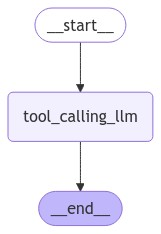

In [11]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

If we pass in `Hello!`, the LLM responds without any tool calls.

In [12]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today?


The LLM chooses to use a tool when it determines that the input or task requires the functionality provided by that tool.

In [13]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_g3zStw5vsHQCjOqqRlfTvBET)
 Call ID: call_g3zStw5vsHQCjOqqRlfTvBET
  Args:
    a: 2
    b: 3
